# Download and prepare `PPFD_IN` (2004-2025)

**notebook version**: `3` (28 Jul 2026)

## ℹ️ About this notebook

Downloads screened photosynthetic photon flux density `PPFD_IN` from InfluxDB, merges the sources
into one continuous series, applies the 2012 corrections and the nighttime zero-offset, gap-fills,
and writes the product to the external data folder.

Same shape as notebooks `01` (`SW_IN`) and `02` (`TA`), with two gap-filling differences noted in
*Method*.

**Output columns:**

- `PPFD_IN_T1_47_1_gfXG` — the gap-filled series (µmol m⁻² s⁻¹, complete, non-negative)
- `FLAG_PPFD_IN_T1_47_1_ISFILLED` — `0` = measured, `>0` = filled (codes in `FLAG_LEGEND` below)

**Notebook `01` has to be run first**: its gap-filled `SW_IN` is a driver here.

***

## 📇 Data sources

- `PPFD_IN_T1_47_1` — ETH, 47 m. **This is the product series.** mst (2004-2021), diive (2022-2025)
- **There is no NABEL PPFD sensor**, so unlike `SW_IN` and `TA` there is no second instrument of
  the same kind. Two radiation drivers stand in for it:
  - `SW_IN_T1_47_1_gfXG` — the gap-filled `SW_IN` from notebook `01`, complete over the whole
    record and physically almost proportional to `PPFD_IN`
  - `SW_IN_LAE_MS` — MeteoSwiss Lägern global radiation, 2.5 km away, read from the reference
    product written by `10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb`. Independent of the tower,
    so it carries a real sky state where the tower `SW_IN` was itself gap-filled
- Measurements start on **2004-09-20**; everything before that is filled — see the export section.

Legend:
- mst ... ETH data, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... ETH data, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "PPFD_IN_T1_47_1"

OUTNAME = "03_METEO_PPFD_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Gap-filled SW_IN produced by notebook 01, used here as the driver.
SWIN_FILE = "01_METEO_SW_IN_GAPFILLED_2004-2025"
SWIN_COL = "SW_IN_T1_47_1_gfXG"

# Reference: MeteoSwiss Lägern global radiation, an independent second radiation driver. Produced
# by 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb. Addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "SW_IN_LAE_MS"

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-28 21:58:24
diive version: v0.91.0


In [3]:
# 0/1/2 are the standard diive gap-filling flags. 3 marks nighttime records set to zero by
# physics and 4 short gaps filled by interpolation, matching the codes used in notebooks 01/02.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = gap-filled by the XGBoost model',
    2: '2 = gap-filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = gap-filled by linear interpolation (short gap)',
}

### Captions

In [4]:
# Captions. Every table and every figure in this notebook carries one, so that a reader meeting a
# number in the rendered page can tell what it is without reading the code that produced it.
# Defined here, above the first cell that calls either. Copied as-is from notebook 02.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    if fig.get_layout_engine() is not None:
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

### Plot helpers

In [5]:
def plot_gapfill_panels(gapfilled, flag, title, ylabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
                        figsize=(16, 7)):
    """Three panels: measured only, the final series, and the fills on their own."""
    _plotdf = pd.DataFrame({
        'observed': gapfilled.where(flag == 0),
        'gapfilled': gapfilled,
        'gap values': gapfilled.where(flag > 0),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=title, legend=True)
    for ax in axs:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    return axs


def plot_pred_vs_measured(model, title, unit=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$'):
    """Predicted against measured on the HELD-OUT test set, plus residuals."""
    test = model.traintest_details_['test_df']
    measured = test[model.target_col].values
    predicted = model.model_.predict(test.drop(columns=model.target_col))
    residual = predicted - measured
    rmse = float(np.sqrt((residual ** 2).mean()))

    fig, axs = plt.subplots(ncols=2, figsize=(13, 5.5), dpi=100, layout='constrained')
    fig.suptitle(f"{title}  (held-out test set, n={len(test):,})", fontsize=13)
    axs[0].hexbin(measured, predicted, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    lim = [float(min(measured.min(), predicted.min())), float(max(measured.max(), predicted.max()))]
    axs[0].plot(lim, lim, 'r-', lw=1.2, label='1:1')
    axs[0].set_xlabel(f'measured {unit}'); axs[0].set_ylabel(f'predicted {unit}')
    axs[0].set_title(f'RMSE {rmse:.2f}   bias {float(residual.mean()):+.2f}', fontsize=11)
    axs[0].legend(fontsize=8)
    axs[1].hexbin(predicted, residual, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    axs[1].axhline(0, color='r', lw=1.2)
    axs[1].set_xlabel(f'predicted {unit}'); axs[1].set_ylabel(f'residual {unit}')
    axs[1].set_title('Residuals', fontsize=11)
    return fig


def fill_stats_by_year(flag, legend=None):
    """Records per year and flag, plus a stacked bar chart of the filled ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    filled = tab.drop(columns=[c for c in tab.columns if str(c).startswith('0 =')], errors='ignore')
    if not filled.empty and filled.to_numpy().sum() > 0:
        ax = filled.plot(kind='bar', stacked=True, figsize=(14, 4), title='Filled records per year')
        ax.set_ylabel('records'); ax.legend(fontsize=8)
        plt.tight_layout()
    return tab

### 🔌 Connect to database

In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

`mst` covers 2004-2021, `diive` covers 2022-2025. They do not overlap.

In [7]:
%%time

BUCKET = 'ch-lae_processed'
MEASUREMENTS = ['PPFD']

mst_ppfd, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[TARGET],
    start='2004-01-01 00:00:01', stop='2022-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_mst')

diive_ppfd, _, _ = dbc.download(
    bucket=BUCKET, measurements=MEASUREMENTS, fields=[TARGET],
    start='2022-01-01 00:00:01', stop='2026-01-01 00:00:01',
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive')

mst_ppfd = TimestampSanitizer(data=mst_ppfd, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()
diive_ppfd = TimestampSanitizer(data=diive_ppfd, output_middle_timestamp=True,
                                nominal_freq=REQUIRED_TIME_RESOLUTION).get()
print(f"mst:   {mst_ppfd[TARGET].notna().sum():,} records")
print(f"diive: {diive_ppfd[TARGET].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_1'] from measurements 
['PPFD'], data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PPFD_IN_T1_47_1'] from measurements 
['PPFD'], data version ['meteoscreening_diive'], between 2022-01-01 00:00:01 and 2026-01-01 00:00:01
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

mst:   300,291 records
diive: 70,046 records
CPU times: total: 3.72 s
Wall time: 6.32 s


### Merge onto one continuous 30MIN index

In [8]:
full_index = pd.date_range('2004-01-01 00:15:00', '2025-12-31 23:45:00', freq='30min',
                           name='TIMESTAMP_MIDDLE')
ppfd_2004_2025 = pd.DataFrame(index=full_index)
ppfd_2004_2025[TARGET] = (mst_ppfd[TARGET]
                          .combine_first(diive_ppfd[TARGET])
                          .reindex(full_index))
print(f"{TARGET}: {ppfd_2004_2025[TARGET].notna().sum():,} of {len(ppfd_2004_2025):,} records")
print(f"first measurement: {ppfd_2004_2025[TARGET].first_valid_index()}")
ppfd_2004_2025

PPFD_IN_T1_47_1: 370,337 of 385,728 records
first measurement: 2004-09-20 10:45:00


,PPFD_IN_T1_47_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,NaN
2004-01-01 00:45:00,NaN
2004-01-01 01:15:00,NaN
2004-01-01 01:45:00,NaN
2004-01-01 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


### Heatmap

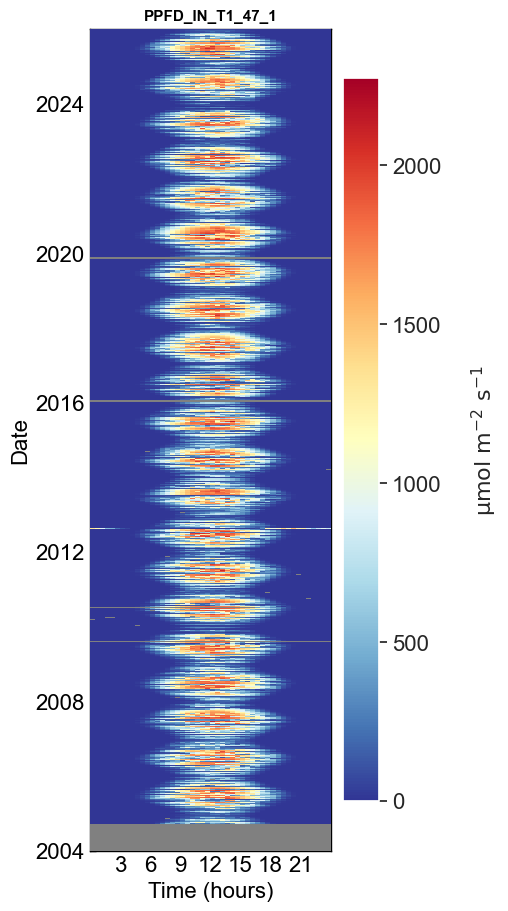

In [9]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=100, layout="constrained")
dv.plotting.HeatmapDateTime(series=ppfd_2004_2025[TARGET]).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
    format_style=dv.plotting.FormatStyle(title=TARGET, title_fontsize=11))

***

## ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

A logger clock error affects every variable that logger recorded. `PPFD_IN` shows the same
`+15.5 h` shift as `SW_IN` and `TA` on 10-16 August, so the same correction is applied.

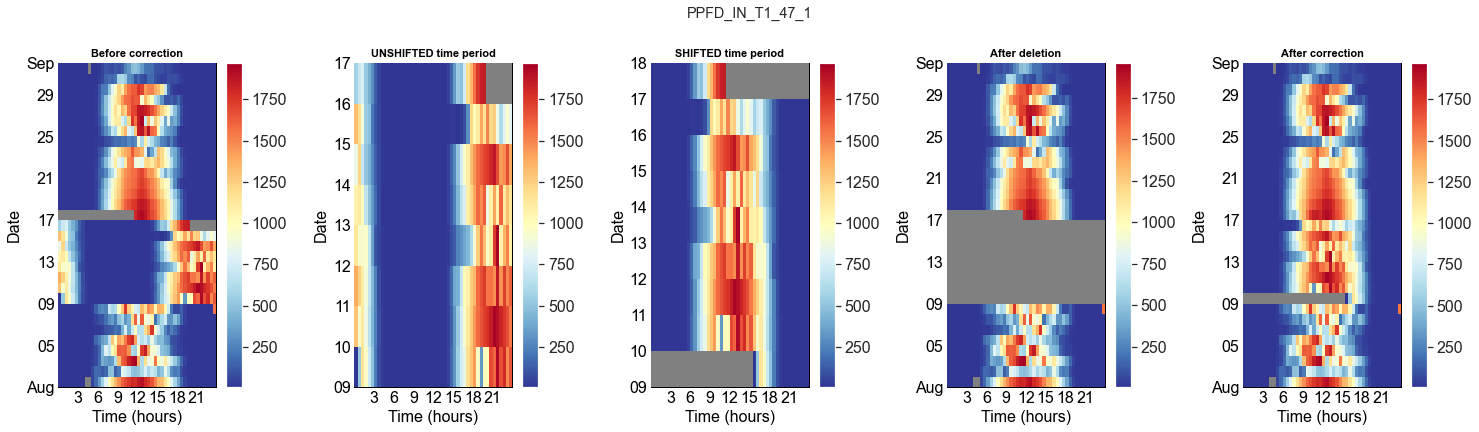

In [10]:
AFFECTED_VARS = [TARGET]
_df = ppfd_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before, ax_unshifted, ax_shifted, ax_after, ax_corrected = [
        fig.add_subplot(gs[0, i]) for i in range(5)]

    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy().dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

In [11]:
ppfd_2004_2025 = _df.copy()
ppfd_2004_2025

,PPFD_IN_T1_47_1
TIMESTAMP_MIDDLE,
2004-01-01 00:15:00,NaN
2004-01-01 00:45:00,NaN
2004-01-01 01:15:00,NaN
2004-01-01 01:45:00,NaN
2004-01-01 02:15:00,NaN
...,...
2025-12-31 21:45:00,0.0
2025-12-31 22:15:00,0.0
2025-12-31 22:45:00,0.0


### Power failure and storm damage, 2012

The same three damaged windows removed in notebooks `01` and `02` apply to `PPFD_IN` as well.
Aligning `PPFD_IN` against the NABEL `SW_IN` sensor (the only instrument at the site not on the
affected logger) day by day, after scaling PPFD to W m-2 equivalent so the errors are comparable:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-28 | 0 | 49 | 49 |
| 2012-08-02 | 0 | 199 | 199 |
| 2012-08-09 | -32.5 h | 151 | 462 |
| **2012-08-11** | **+15.5 h** | **48** | 572 |
| **2012-08-16** | **+15.5 h** | **78** | 460 |
| 2012-08-18 | 0 | 34 | 34 |
| 2012-10-27 | 0 | 11 | 11 |
| 2012-10-30 | -24.0 h | 178 | 210 |
| 2012-11-05 | -24.0 h | 146 | 172 |
| 2012-11-11 | 0 | 6 | 6 |

The picture matches `SW_IN` and `TA` exactly: a clean `+15.5 h` clock offset on 10-16 August
(fixed by the correction above), an unrepairable degradation from 29 July to 9 August, and a
second unrepairable period from late October to early November. The fieldbook attributes the
first to a tower power supply failure repaired on 9 August, and the second to storm damage with
cable work on 6 November. Notebooks `01` and `02` document the evidence in full.

Windows are on the **corrected** time axis and are identical to those used there.

Removed 1213 degraded records from PPFD_IN_T1_47_1 (gap-filled later).


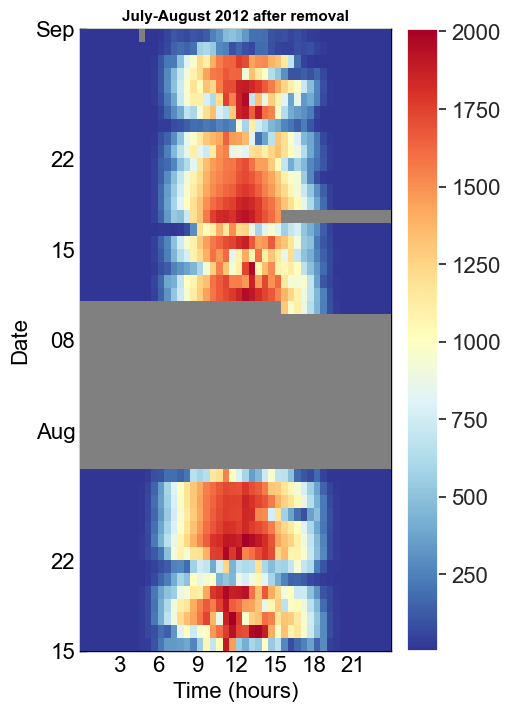

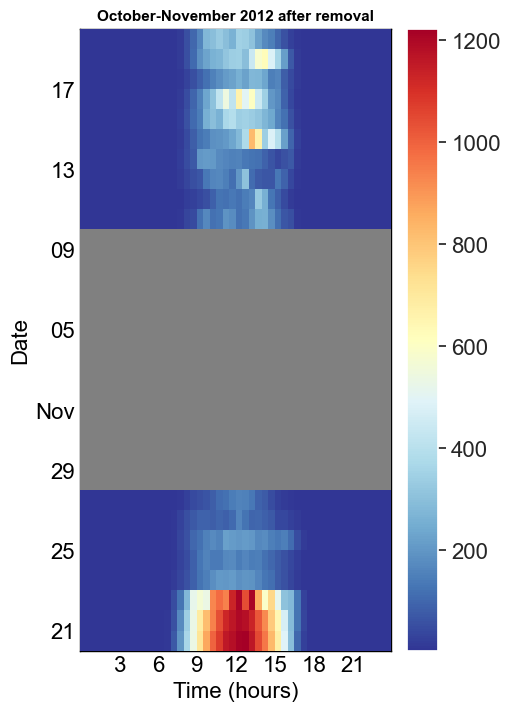

In [12]:
# Identical to the windows removed in notebooks 01 and 02 - the faults are in the logger and
# the power supply, so every variable on that system is affected.
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

_before = int(ppfd_2004_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (ppfd_2004_2025.index >= _start) & (ppfd_2004_2025.index <= _end)
    ppfd_2004_2025.loc[_locs, TARGET] = np.nan
_removed = _before - int(ppfd_2004_2025[TARGET].notna().sum())
print(f"Removed {_removed} degraded records from {TARGET} (gap-filled later).")

for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, ax = plt.subplots(figsize=(5, 7), dpi=100, layout="constrained")
    _show = (ppfd_2004_2025.index >= _lo) & (ppfd_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=ppfd_2004_2025.loc[_show, TARGET]).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='',
        format_style=dv.plotting.FormatStyle(
            title=f'{_label} 2012 after removal', title_fontsize=11))

### Nighttime zero-offset

`PPFD_IN` must read zero at night. A sensor that does not is carrying an offset, which
`dv.corrections.remove_nighttime_zero_offset` removes: for each day it takes the mean of that
day's nighttime values as the offset, subtracts it from the whole day, then sets nighttime to
zero and clamps the remaining negatives to zero. It is the same routine notebook `01` applies to
`SW_IN` through `correct_nighttime_offset=True`, called directly here because `PPFD_IN` has no
dedicated gap-filling class.

**The gap mask has to be taken before this step.** The correction sets every nighttime record to
zero, and it does not distinguish a nighttime measurement from a nighttime gap — the missing ones
become zero too. Asking the corrected series which records are missing therefore reports no
nighttime gaps at all, and they would be exported as `0 = observed` when they are really fills.
`PPFD_ORIGINAL_GAPS` is captured first and carried into the gap-filler, which flags them `3`.

gaps before correction: 16,604


> running remove_nighttime_zero_offset ...

before: min 0.00, records below zero: 0
after : min 0.00, records below zero: 0
mean change on measured records: -2.935 umol m-2 s-1
nighttime gaps zeroed by the correction: 7,543 (fills, not measurements - flagged 3 by the gap-filler)


,PPFD_IN_T1_47_1
count,376667.000000
mean,284.502278
std,484.057175
min,0.000000
25%,0.000000
50%,2.655310
75%,358.031093
max,2271.086339


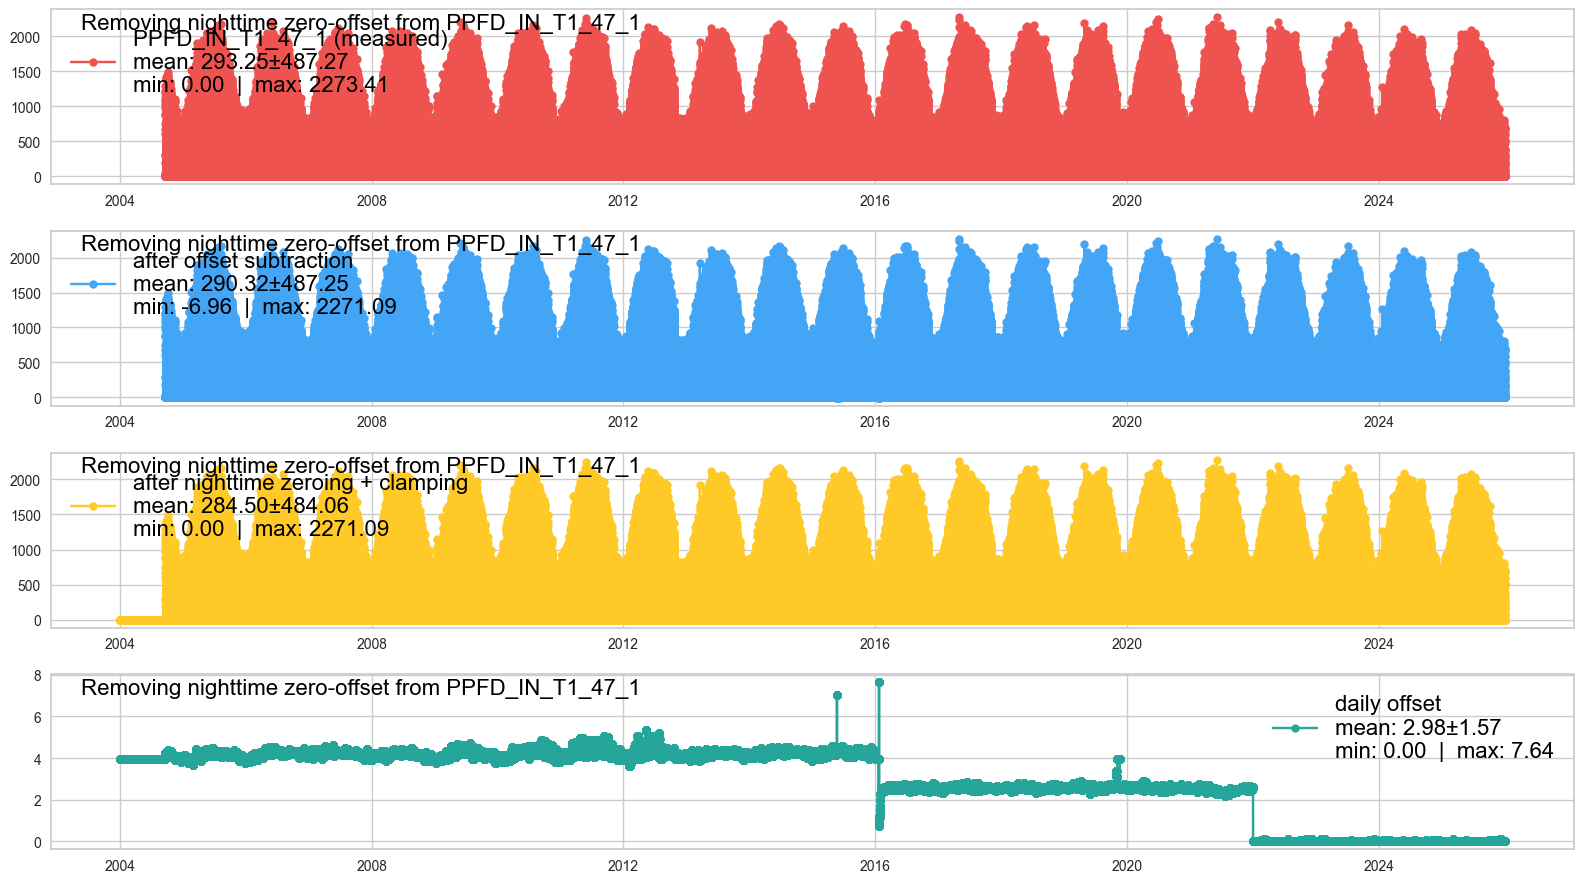

In [13]:
# Capture the gap mask BEFORE correcting. remove_nighttime_zero_offset() sets EVERY
# nighttime record to zero, including the missing ones, so afterwards a nighttime gap is
# indistinguishable from a nighttime measurement. Without this mask those filled zeros
# would reach the export flagged 0 = observed.
PPFD_ORIGINAL_GAPS = ppfd_2004_2025[TARGET].isna()
print(f"gaps before correction: {int(PPFD_ORIGINAL_GAPS.sum()):,}")

ppfd_corrected = dv.corrections.remove_nighttime_zero_offset(
    series=ppfd_2004_2025[TARGET].copy(),
    lat=SITE_LAT, lon=SITE_LON, utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    showplot=True, clamp_negatives=True,
)

_before = ppfd_2004_2025[TARGET]
print(f"before: min {_before.min():.2f}, records below zero: {(_before < 0).sum():,}")
print(f"after : min {ppfd_corrected.min():.2f}, records below zero: {(ppfd_corrected < 0).sum():,}")
print(f"mean change on measured records: {float((ppfd_corrected - _before).mean()):+.3f} umol m-2 s-1")
print(f"nighttime gaps zeroed by the correction: "
      f"{int((PPFD_ORIGINAL_GAPS & ppfd_corrected.notna()).sum()):,} "
      f"(fills, not measurements - flagged 3 by the gap-filler)")

ppfd_2004_2025[TARGET] = ppfd_corrected
ppfd_2004_2025.describe()

***

## 🟦 Drivers

`PPFD_IN` and `SW_IN` are two measurements of essentially the same flux in different units, so
the gap-filled `SW_IN` from notebook `01` is a far stronger driver than anything derived from the
timestamp. `SW_IN_POT` is added as well: it never has gaps and carries sun angle and season, which
is what separates a clear morning from a clear afternoon of equal `SW_IN`.

A third driver, **MeteoSwiss Lägern global radiation** (`SW_IN_LAE_MS`), is added below. The
tower `SW_IN` driver is complete only because notebook `01` gap-filled it; at those positions it
is a model output, and `PPFD_IN` gaps tend to coincide with `SW_IN` gaps (same faults). Lägern is
an independent measurement 2.5 km away, so it supplies a real sky state exactly where the tower
driver is weakest.

Because all three drivers span the whole record, there is **no need to split into periods**,
unlike notebooks `01` and `02` where the NABEL sensor stopped in 2018.

In [14]:
swin_gf = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{SWIN_FILE}.parquet"))
print(f"Loaded {SWIN_FILE}: {list(swin_gf.columns)}")

drivers = pd.DataFrame(index=ppfd_2004_2025.index)
drivers[SWIN_COL] = swin_gf[SWIN_COL]  # keeps the name it has in the file
drivers['SW_IN_POT'] = dv.variables.potrad(
    timestamp_index=ppfd_2004_2025.index, lat=SITE_LAT, lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)

print(drivers.isnull().sum().rename('missing values'))
drivers.describe()

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet (0.031 seconds).

Loaded 01_METEO_SW_IN_GAPFILLED_2004-2025: ['SW_IN_T1_47_1_gfXG', 'FLAG_SW_IN_T1_47_1_ISFILLED']


SW_IN_T1_47_1_gfXG    0
SW_IN_POT             0
Name: missing values, dtype: int64


,SW_IN_T1_47_1_gfXG,SW_IN_POT
count,385728.000000,385728.000000
mean,145.881536,298.951202
std,240.172173,382.633189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,4.033335,17.494992
75%,197.979111,566.632430
max,1118.658439,1214.125501


### 🌍 MeteoSwiss Lägern

Lägern global radiation, added to `drivers` as an independent second radiation predictor. It
carries `TIMESTAMP_END`; this notebook works on `TIMESTAMP_MID`, so the index is shifted back 15
minutes (the midpoint of a 30MIN bin). The guard correlates it against the measured tower
`PPFD_IN` on daytime records — same physics, different units — and asserts offset 0 wins, so a
mis-shifted reference cannot silently teach the model the wrong daily cycle.

In [15]:
ppfd_ref = pd.read_parquet(REFPATH)[[REFCOL]]
ppfd_ref.index = ppfd_ref.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
ppfd_ref.index.name = ppfd_2004_2025.index.name

_meas = ppfd_2004_2025[TARGET]
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), ppfd_ref[REFCOL].shift(_off).rename('r')], axis=1).dropna()
    _j = _j[_j['r'] > 20]  # daytime only: at night both are ~0 and carry no timing information
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: daytime corr {_scores[_off]:.4f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

drivers[REFCOL] = ppfd_ref[REFCOL]
print(f"\n{REFCOL} available for {drivers[REFCOL].notna().mean() * 100:.2f}% of records")
drivers.describe()

  offset -1 x 30min: daytime corr 0.9252
  offset +0 x 30min: daytime corr 0.9629
  offset +1 x 30min: daytime corr 0.9077
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.

SW_IN_LAE_MS available for 99.58% of records


,SW_IN_T1_47_1_gfXG,SW_IN_POT,SW_IN_LAE_MS
count,385728.000000,385728.000000,384126.000000
mean,145.881536,298.951202,141.513118
std,240.172173,382.633189,231.392431
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000
50%,4.033335,17.494992,5.333333
75%,197.979111,566.632430,189.333333
max,1118.658439,1214.125501,1155.333333


***

***

## 🔎 A falling sensor response since 2021

`PPFD_IN_T1_47_1` is **declining relative to both of the radiation references used here**, by
several per cent since 2021, and the record ends while it is still falling. This is a property of
the exported product, not of the gap-filling, and it is recorded here so that a user of the series
meets it in the documentation rather than in a trend.

The attribution is made in `RADIATION_SENSOR_CONTINUITY.ipynb`, which compares four radiation
sensors and shows that the two ratios containing this sensor move while the ratio between the
other two does not — which places the change on the PAR sensor rather than on either reference.
This section reproduces the size of it on this notebook's own data, and asserts it, so that the
statement cannot go stale while the notebook still runs.

The two references are independent of each other in the way that matters. MeteoSwiss Lägern is a
different institution's instrument 2.5 km away. The tower `SW_IN` is a different instrument with
different optics and its own calibration, 47 m up the same mast — it shares this sensor's tower,
logger and maintenance history, but not the part of the measurement chain a response drift lives
in. A decline against both at once is a change here.

In [16]:
# Measured records only, on both sides. The SW_IN driver is complete because notebook 01 filled
# it, and a modelled value is partly a function of the MeteoSwiss series it would then be compared
# against, so the fill flag is used to keep them out.
SWIN_FLAG = "FLAG_SW_IN_T1_47_1_ISFILLED"
_cmp = pd.DataFrame({
    'ppfd': ppfd_2004_2025[TARGET],                                 # measured; gap-filling is below
    'tower SW_IN': swin_gf[SWIN_COL].where(swin_gf[SWIN_FLAG] == 0),
    'MeteoSwiss': drivers[REFCOL],
})

# The same controls as the SW_IN notebook, and for the same reasons: potential radiation is
# astronomical so it cannot drift, and April-September excludes snow, rime and the low-sun
# geometry that would otherwise read as a response change.
_potrad = dv.variables.potrad(timestamp_index=_cmp.index, lat=SITE_LAT, lon=SITE_LON,
                              utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS)
_usable = (_potrad > 300) & _cmp.index.month.isin([4, 5, 6, 7, 8, 9])
BASELINE_YEARS = (2006, 2010)


def ppfd_ratio_by_year(other: str, min_records: int = 100) -> pd.Series:
    """Month-matched yearly median of PPFD_IN divided by `other`, over usable half-hours.

    Monthly medians first, then the mean over calendar months, so a year short of one month is
    not compared against one that is not. Raises rather than returning a thin result: a ratio
    built from a handful of half-hours reads exactly like one built from a thousand.
    """
    _j = _cmp.loc[_usable, ['ppfd', other]].dropna()
    _j = _j[(_j['ppfd'] > 50) & (_j[other] > 50)]
    if len(_j) < min_records * 12:
        raise ValueError(f"PPFD_IN / {other}: only {len(_j)} usable half-hours, too few")
    _r = _j['ppfd'] / _j[other]
    _m = _r.groupby([_r.index.year, _r.index.month]).median()
    _m.index.names = ['year', 'month']
    _n = _r.groupby([_r.index.year, _r.index.month]).count()
    _m = _m[_n >= min_records]
    if _m.empty:
        raise ValueError(f"PPFD_IN / {other}: no calendar month reaches {min_records} records")
    return _m.groupby(level=0).mean()


# The guard guards: fed a threshold no month can meet, the helper must refuse rather than return
# a ratio computed from almost nothing.
try:
    ppfd_ratio_by_year('MeteoSwiss', min_records=1_000_000)
except ValueError as _exc:
    print(f"OK, ppfd_ratio_by_year raised on a threshold no data can meet: {_exc}")
else:
    raise AssertionError("(!) ppfd_ratio_by_year accepted a threshold no data can meet.")

response = pd.DataFrame({_o: ppfd_ratio_by_year(_o) for _o in ('tower SW_IN', 'MeteoSwiss')})
response.index.name = 'YEAR'
response_rel = 100 * (response / response.loc[BASELINE_YEARS[0]:BASELINE_YEARS[1]].mean() - 1)

tabcap(f"the response of PPFD_IN relative to each radiation reference, as a percentage of its own "
       f"{BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} level. Only well-lit April-September half-hours "
       f"enter, as monthly medians averaged over calendar months, so neither the season nor how "
       f"sunny a year was can move a row")
display(response_rel.round(2))

DECLINE_FROM = 2021
_last = int(response_rel.index.max())
_fall = (response_rel.loc[_last] - response_rel.loc[DECLINE_FROM])
print(f"\nchange in the response of PPFD_IN from {DECLINE_FROM} to {_last}:")
for _o, _v in _fall.items():
    print(f"  against {_o:<14s} {_v:+.2f} %   "
          f"(and {response_rel.loc[_last, _o]:+.2f} % against {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]})")

# The product is exported as measured, so this is a limitation rather than something corrected.
# The assertion exists so the limitation cannot quietly stop being true, in either direction: if
# the decline reverses, the text above is wrong; if it deepens past a tenth of the signal, this
# notebook should not be exporting the series without saying considerably more.
assert (_fall < -2.0).all(), (
    "PPFD_IN no longer falls against both references since 2021 - the limitation described here "
    "and on the documentation page must be re-derived rather than left in place")
assert (response_rel.loc[_last] > -10.0).all(), (
    "the decline has passed 10 % of the baseline response - it is no longer a limitation to note "
    "in passing and the product needs a decision rather than a paragraph")
print("\nThe decline is present against both references and is still in progress at the end of "
      "the record.")

OK, ppfd_ratio_by_year raised on a threshold no data can meet: PPFD_IN / MeteoSwiss: only 83967 usable half-hours, too few
Table - the response of PPFD_IN relative to each radiation reference, as a percentage of its own
2006-2010 level. Only well-lit April-September half-hours enter, as monthly medians averaged over
calendar months, so neither the season nor how sunny a year was can move a row



,tower SW_IN,MeteoSwiss
YEAR,,
2004,NaN,-2.23
2005,-2.20,-1.01
2006,0.42,-0.30
2007,0.45,0.62
2008,-0.07,-0.40
2009,-0.15,-0.30
2010,-0.65,0.38
2011,1.29,-4.00
2012,0.20,-4.08



change in the response of PPFD_IN from 2021 to 2025:
  against tower SW_IN    -3.28 %   (and -6.05 % against 2006-2010)
  against MeteoSwiss     -3.72 %   (and -7.40 % against 2006-2010)

The decline is present against both references and is still in progress at the end of the record.


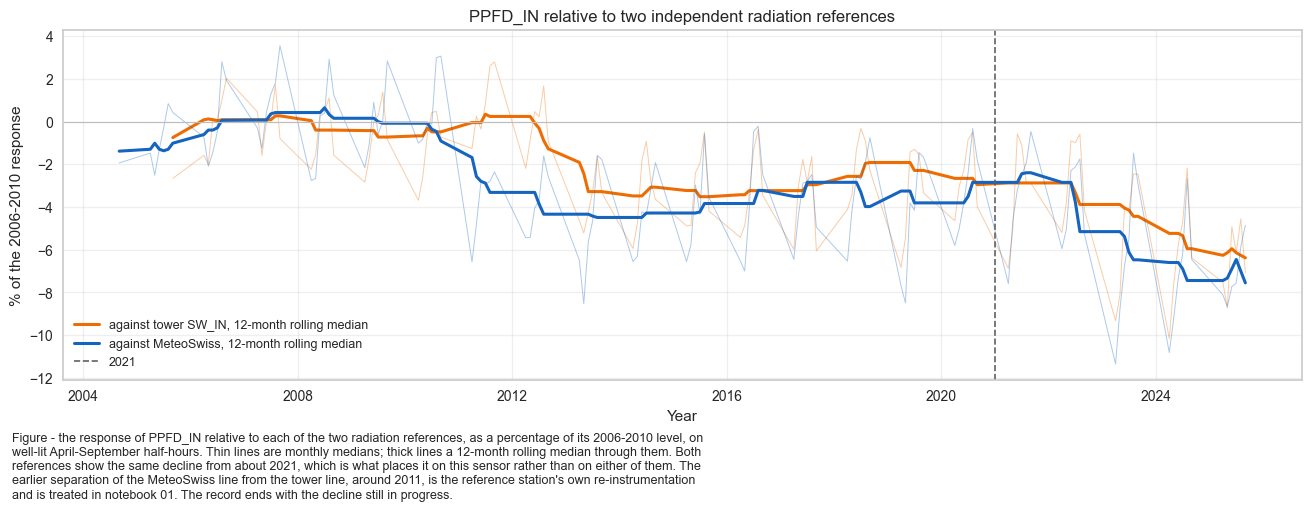

In [17]:
# Drawn as monthly medians behind a 12-month rolling median: this is a drift, not a step, and a
# yearly table cannot show whether it has levelled off. It has not.
fig, ax = plt.subplots(figsize=(13, 5), dpi=100, layout="constrained")
for _o, _colour in [('tower SW_IN', '#EF6C00'), ('MeteoSwiss', '#1565C0')]:
    _j = _cmp.loc[_usable, ['ppfd', _o]].dropna()
    _j = _j[(_j['ppfd'] > 50) & (_j[_o] > 50)]
    _r = (_j['ppfd'] / _j[_o])
    _monthly = _r.resample('MS').median()
    _monthly = _monthly[_r.resample('MS').count() >= 100]
    _rel = 100 * (_monthly / _monthly.loc[f'{BASELINE_YEARS[0]}':f'{BASELINE_YEARS[1]}'].median() - 1)
    ax.plot(_rel.index, _rel, color=_colour, lw=0.7, alpha=0.35)
    ax.plot(_rel.index, _rel.rolling(12, center=True, min_periods=6).median(), color=_colour,
            lw=2.2, label=f'against {_o}, 12-month rolling median')
ax.axhline(0, color='#BDBDBD', lw=0.8)
ax.axvline(pd.Timestamp(f'{DECLINE_FROM}-01-01'), color='#616161', lw=1.2, ls='--',
           label=f'{DECLINE_FROM}')
ax.set_xlabel("Year")
ax.set_ylabel(f"% of the {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]} response")
ax.set_title("PPFD_IN relative to two independent radiation references")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='lower left')
figcap(fig, "the response of PPFD_IN relative to each of the two radiation references, as a "
            "percentage of its 2006-2010 level, on well-lit April-September half-hours. Thin "
            "lines are monthly medians; thick lines a 12-month rolling median through them. Both "
            "references show the same decline from about 2021, which is what places it on this "
            "sensor rather than on either of them. The earlier separation of the MeteoSwiss line "
            "from the tower line, around 2011, is the reference station's own re-instrumentation "
            "and is treated in notebook 01. The record ends with the decline still in progress.")

::: {.callout-warning title="Known limitation of this product"}

`PPFD_IN_T1_47_1` is exported **as measured**. No correction is applied for the decline above, for
two reasons: it develops over years rather than stepping at a date, so there is no boundary at
which a correction could be applied; and no maintenance record identifies a cause, so any
correction would be a rescaling towards a reference rather than a repair of a known fault.

The practical consequences:

- A **trend** computed over the last years of this record, or across 2021, contains the sensor's
  own decline as well as any change in the light. The size of it is in the table above.
- Comparisons **within** a year, and the relation between `PPFD_IN` and the other radiation
  variables at a given time, are unaffected.
- Gap-filled records inherit the state of the sensor at the time they were filled, because the
  model is trained on the measurements around them. They neither add the bias nor remove it.

The likeliest cause of a falling response in a quartz-domed quantum sensor left in the field is
the sensor itself — soiling, or ageing of the diffuser and the detector. A calibration or a
replacement would settle it, and until one happens the decline can only be reported.

:::

## 🟥 Gap-filling

### Method

There is no `PPFD_IN`-specific gap-filling class in diive, so this uses the general `XGBoostTS`
with an explicit `FeatureEngineer`, as notebook `02` does for `TA`. Two settings differ from the
temperature case, both because `PPFD_IN` is a radiation quantity:

- **`below_zero='zero'`** — negative predictions are clipped. Temperature can be negative,
  photon flux cannot.
- **Nighttime gaps are set to zero by physics** after modelling, and flagged `3`. There is no
  photosynthetically active radiation at night, so a modelled value there would be noise around a
  known answer. This mirrors what `SWINGapFillerXGBoost` does internally in notebook `01`.

Otherwise the configuration follows notebook `02`: no lag features (a lag of a gappy driver
demotes records to the timestamp-only fallback), `SW_IN_POT` excluded from the rolling and EMA
stages (smoothing a deterministic timestamp curve adds nothing), SHAP capped at 10,000 rows, and
short daytime gaps filled by interpolation afterwards and flagged `4`.

In [18]:
SHAP_MAX_ROWS = 10_000
NIGHTTIME_THRESHOLD = 0.001  # SW_IN_POT below this counts as night, as in notebook 01


def short_gap_mask(missing: pd.Series, limit: int) -> pd.Series:
    """True where `missing` is set AND its whole run is at most `limit` records long.

    Takes a boolean gap mask rather than the series itself, so the caller can pass the
    mask from before the nighttime offset correction.
    """
    run_length = missing.groupby((~missing).cumsum()).transform('sum')
    return missing & (run_length <= limit)


def gapfill_ppfd(target: pd.Series,
                 drivers: pd.DataFrame,
                 swinpot: pd.Series,
                 original_gaps: pd.Series,
                 interpolate_limit: int = 2,
                 reduce_features: bool = True,
                 verbose: int = 1):
    """Gap-fill PPFD with XGBoost, force nighttime to zero, interpolate short daytime gaps.

    `original_gaps` must be the gap mask from BEFORE the nighttime offset correction:
    that correction zeroes every nighttime record including the missing ones, so
    `target.isna()` here would report no nighttime gaps at all and label them as measured.

    Returns (model, gapfilled, flag).
    """
    daytime = swinpot >= NIGHTTIME_THRESHOLD

    input_df = pd.concat([target, drivers], axis=1)
    engineer = dv.gapfilling.FeatureEngineer(
        target_col=target.name,
        features_lag=[],
        features_rolling=[4, 8, 24, 48],
        features_rolling_stats=['median'],
        features_rolling_exclude_cols=['SW_IN_POT'],
        features_ema=[6, 24],
        features_ema_exclude_cols=['SW_IN_POT'],
        vectorize_timestamps=True,
        add_continuous_record_number=True,
        verbose=0,
    )
    features_df = engineer.fit_transform(input_df)
    print(f"Features: {features_df.shape[1] - 1} over {len(features_df):,} records")

    model = dv.gapfilling.XGBoostTS(
        input_df=features_df, target_col=target.name, verbose=verbose,
        below_zero='zero',           # photon flux cannot be negative
        shap_max_rows=SHAP_MAX_ROWS,
        n_estimators=3000, max_depth=6, early_stopping_rounds=20,
        random_state=42, n_jobs=-1,
    )
    model.trainmodel(showplot_scores=False, showplot_importance=False)
    if reduce_features:
        model.reduce_features()
        model.trainmodel(showplot_scores=False, showplot_importance=False)
    model.fillgaps(showplot_scores=False, showplot_importance=False)

    gapfilled = model.results.gapfilled.copy()
    flag = model.results.flag.copy()

    # Physics beats the model at night: no incoming PAR after sunset.
    night_gaps = original_gaps & ~daytime
    gapfilled[night_gaps] = 0.0
    flag[night_gaps] = 3
    print(f"Nighttime gaps set to 0: {int(night_gaps.sum()):,}")

    # Short DAYTIME gaps only - a night is already handled above. The run-length search
    # uses the pre-correction mask for the same reason as above.
    if interpolate_limit:
        short = short_gap_mask(original_gaps, interpolate_limit) & daytime
        interp = target.interpolate(method='time', limit_area='inside')
        fill_locs = short & interp.notna()
        gapfilled[fill_locs] = interp[fill_locs]
        flag[fill_locs] = 4
        print(f"Short-gap interpolation: {int(fill_locs.sum())} records")

    gapfilled = gapfilled.rename(f"{target.name}_gfXG")
    flag = flag.rename(f"FLAG_{target.name}_ISFILLED")
    return model, gapfilled, flag

### Run gap-filling

In [19]:
%%time

gf_ppfd, gapfilled_ppfd, flag_ppfd = gapfill_ppfd(
    target=ppfd_2004_2025[TARGET],
    drivers=drivers,
    swinpot=drivers['SW_IN_POT'],
    original_gaps=PPFD_ORIGINAL_GAPS,  # from BEFORE the offset correction, see there
)

Features: 46 over 385,728 records


! Some features are incomplete (<385728 values): SW_IN_LAE_MS (384126), .SW_IN_LAE_MS_MEAN4 
(384161), .SW_IN_LAE_MS_SD4 (384161), .SW_IN_LAE_MS_MEAN8 (384186), .SW_IN_LAE_MS_SD8 (384186), 
.SW_IN_LAE_MS_MEAN24 (384232), .SW_IN_LAE_MS_SD24 (384232), .SW_IN_LAE_MS_MEAN48 (384239), 
.SW_IN_LAE_MS_SD48 (384239), .SW_IN_LAE_MS_ROLLMEDIAN4 (384161), .SW_IN_LAE_MS_ROLLMEDIAN8 (384186),
.SW_IN_LAE_MS_ROLLMEDIAN24 (384232), .SW_IN_LAE_MS_ROLLMEDIAN48 (384239), .SW_IN_LAE_MS_EMA6 
(384239), .SW_IN_LAE_MS_EMA24 (384239)

! Not all target values can be predicted based on the full model.

> ++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', 
'.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', 
'.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] (ONLY 
FALLBACK)

Nighttime gaps set to 0: 7,543
Short-gap interpolation: 87 records
CPU times: total: 20min 53s
Wall time: 59 s


### Results: scores and feature importances

In [20]:
print("Held-out (train/test) scores:")
display(pd.Series(gf_ppfd.results.scores_traintest))
print("Flag counts:")
display(flag_ppfd.value_counts().sort_index().rename(index=FLAG_LEGEND))

Held-out (train/test) scores:


mae      8.161312e+00
medae    1.427741e+00
mse      5.030504e+02
rmse     2.242879e+01
mape     1.511145e+15
maxe     1.262649e+03
r2       9.978676e-01
dtype: float64

Flag counts:


FLAG_PPFD_IN_T1_47_1_ISFILLED
0 = observed                                                                  369124
1 = gap-filled by the XGBoost model                                             8374
2 = gap-filled by the timestamp-only fallback model (a driver was missing)       600
3 = nighttime gap, set to zero by physics                                       7543
4 = gap-filled by linear interpolation (short gap)                                87
Name: count, dtype: int64

In [21]:
gf_ppfd.results.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_T1_47_1_gfXG,286.999939,237.178268
SW_IN_LAE_MS,64.656197,84.092285
SW_IN_POT,11.911252,7.140404
.DOY_COS,6.963439,6.024593
.SW_IN_T1_47_1_gfXG_MEAN48,6.896213,6.728474
.YEARWEEK,5.796655,6.845006
.SW_IN_T1_47_1_gfXG_ROLLMEDIAN4,5.464215,6.031366
.SW_IN_T1_47_1_gfXG_MEAN4,5.384974,3.335186
.SW_IN_LAE_MS_MEAN48,4.565189,4.930974
.SW_IN_LAE_MS_SD48,3.963548,3.240794


#### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything implausible there is worth following
up, because it is invisible in the combined series.

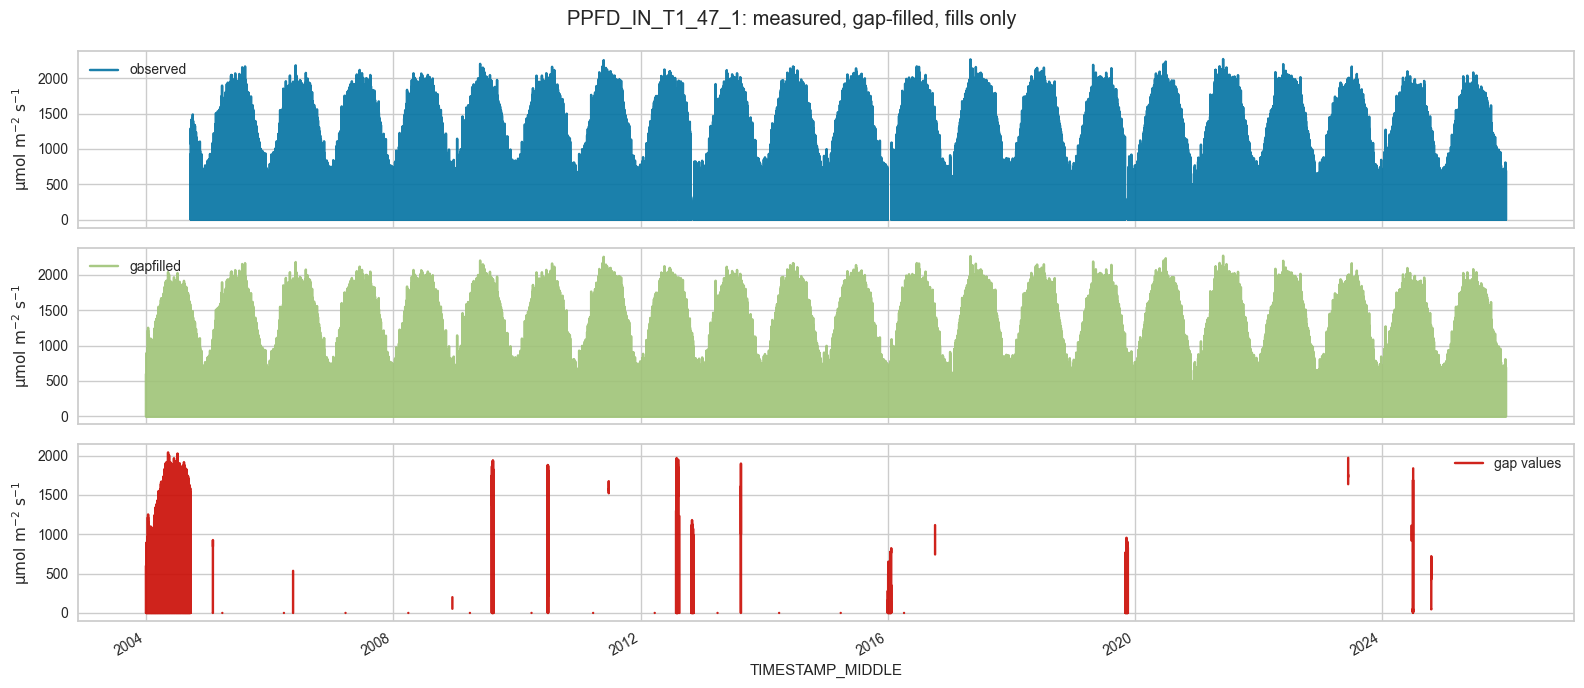

In [22]:
plot_gapfill_panels(gapfilled_ppfd, flag_ppfd,
                    title=f"{TARGET}: measured, gap-filled, fills only");

#### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this shows whether it is actually any good.

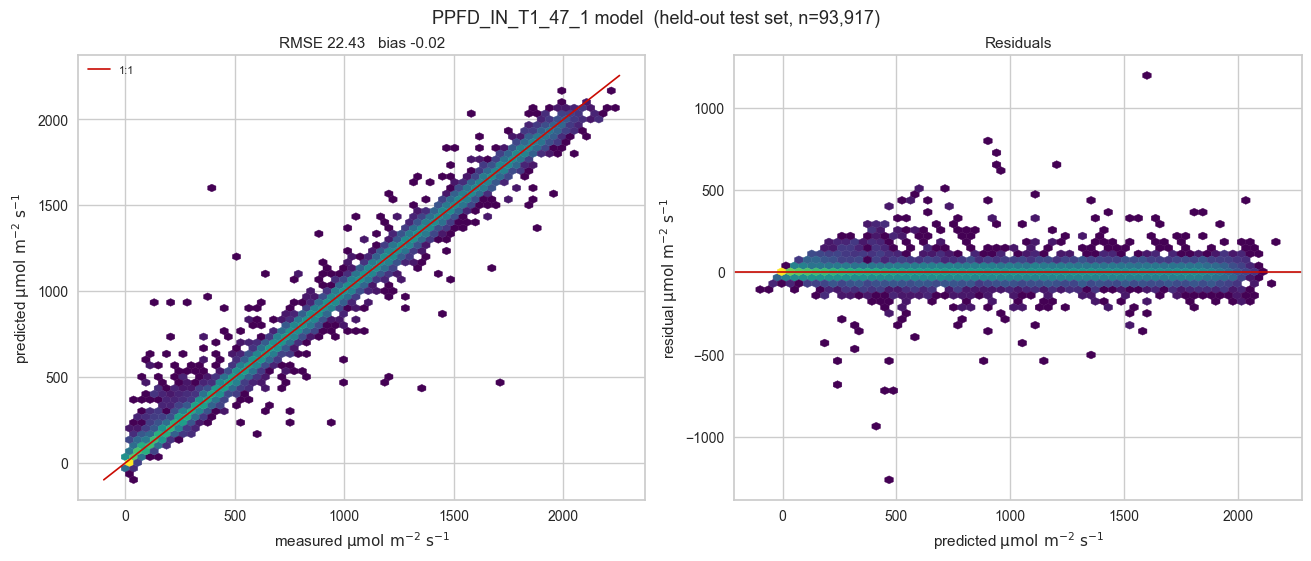

In [23]:
plot_pred_vs_measured(gf_ppfd, title=f"{TARGET} model");

***

## ➡️ Prepare dataframe for export

In [24]:
VALCOL = f"{TARGET}_gfXG"
FLAGCOL = f"FLAG_{TARGET}_ISFILLED"

export_df = pd.concat([gapfilled_ppfd, flag_ppfd], axis=1)
export_df

,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


Sanity check: the exported series must be complete, non-negative, on a continuous 30MIN index
with no duplicates, and every record must carry a flag.

`FLAG_PPFD_IN_T1_47_1_ISFILLED` travels with the product so downstream notebooks can tell measured
from filled records.

In [25]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")
print(f"Min / max:       {export_df[VALCOL].min():.2f} / {export_df[VALCOL].max():.2f}")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
display(pd.DataFrame({'count': _counts,
                      '%': (100 * _counts / len(export_df)).round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

export_df.describe()

Records:         385728
Missing values:  0
Negative values: 0
Missing flags:   0
Duplicate index: 0
Index gaps:      0
Min / max:       0.00 / 2271.09

Fill provenance:


,count,%
FLAG_PPFD_IN_T1_47_1_ISFILLED,,
0 = observed,369124,95.70
1 = gap-filled by the XGBoost model,8374,2.17
2 = gap-filled by the timestamp-only fallback model (a driver was missing),600,0.16
"3 = nighttime gap, set to zero by physics",7543,1.96
4 = gap-filled by linear interpolation (short gap),87,0.02


Measured: 95.70%  |  Filled: 4.30%


,PPFD_IN_T1_47_1_gfXG,FLAG_PPFD_IN_T1_47_1_ISFILLED
count,385728.000000,385728.000000
mean,292.152648,0.084388
std,488.310415,0.447679
min,0.000000,0.000000
25%,0.000000,0.000000
50%,6.523007,0.000000
75%,380.219096,0.000000
max,2271.086339,4.000000


### Fill statistics per year

**Note on 2004.** `PPFD_IN` measurements only start on 20 September 2004, so everything before
that is modelled. Those records are filled from the gap-filled `SW_IN` of notebook `01`, which is
itself reconstructed for 2004 from the NABEL sensor. They are therefore a fill built on a fill and
carry the uncertainty of both steps. The flag marks them, so they can be excluded where that
matters.

,0 = observed,1 = gap-filled by the XGBoost model,2 = gap-filled by the timestamp-only fallback model (a driver was missing),"3 = nighttime gap, set to zero by physics",4 = gap-filled by linear interpolation (short gap)
year,,,,,
2004,4922,6518,571,5556,1
2005,17485,10,0,17,8
2006,17493,5,0,14,8
2007,17507,0,0,6,7
2008,17548,4,0,8,8
2009,17036,292,0,184,8
2010,17351,109,0,55,5
2011,17499,10,0,6,5
2012,16310,627,29,596,6


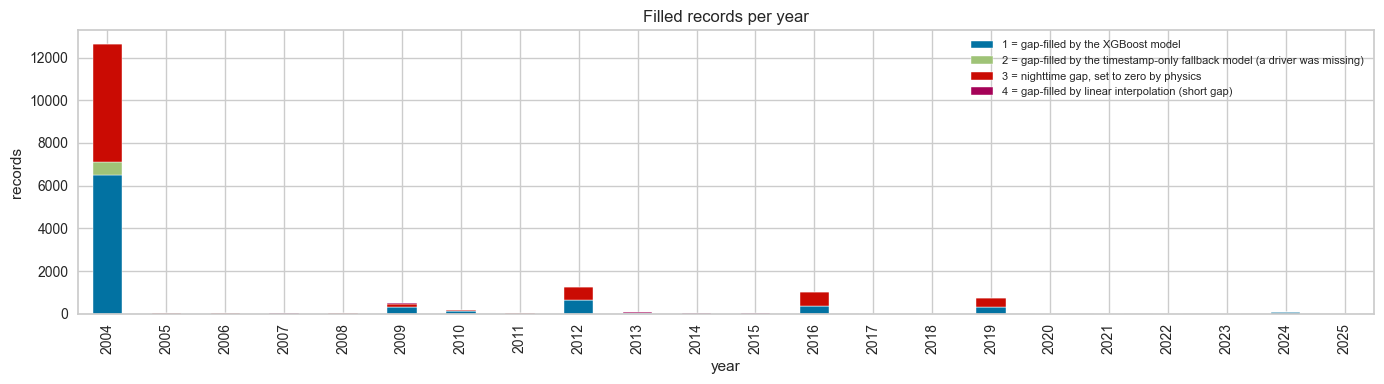

In [26]:
fill_stats_by_year(export_df[FLAGCOL])

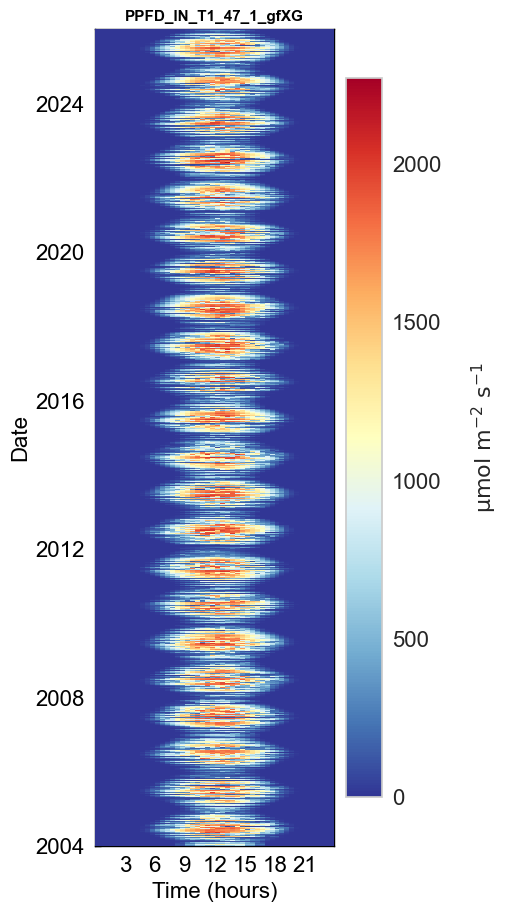

In [27]:
fig, ax = plt.subplots(figsize=(5, 9), dpi=100, layout="constrained")
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=ax, cb_digits_after_comma=0, zlabel=r'$\mathrm{\mu mol\ m^{-2}\ s^{-1}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

***

## 💾 Save to file

In [28]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet (0.031 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\03_METEO_PPFD_IN_GAPFILLED_2004-2025.parquet


***

## End of notebook.

In [29]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-28 21:58:24
Finished: 2026-07-28 21:59:49
Runtime:  00:01:24 (hh:mm:ss)
